# 03 — Dataset Analysis

**Thesis:** Structured Subsystem-Aware Feature Representations for Predictive Maintenance in Metro Systems  
**Author:** Emirhan Kurtulus, TU Wien

Analyzes the supervised and unsupervised datasets created in NB02, validates alignment with
Steiner's baseline, and examines feature characteristics by subsystem.

**Sections:**
1. Supervised dataset overview & label distribution
2. Comparison with Steiner's baseline predictions
3. Feature distributions (normal vs failure)
4. Subsystem-level feature analysis
5. Unsupervised dataset overview & standardization check
6. Temporal coverage & gap analysis

## 0. Setup

In [1]:
import sys, os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
from src.config import SUBSYSTEMS

ROOT = os.path.abspath('..')
SUP_DIR   = os.path.join(ROOT, 'outputs', 'supervised')
UNSUP_DIR = os.path.join(ROOT, 'outputs', 'unsupervised')
STEINER_PREDS = os.path.join(ROOT, 'references', 'stefan', 'supervised_test_predictions.csv')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Sensor subsystem mapping
EXCLUDED_CONTEXT = {
    'TRAIN_LINE', 'TRAIN_CURRENT_SECTION', 'TRAIN_IS_SPECIAL_SECTION',
    'TRAIN_MANUAL_MODE', 'TRAIN_AUTOMATIC_MODE', 'TRAIN_EMERGENCY_MODE',
}
BINARY_SENSORS = [
    'CW1_SPRING_BRAKE_ACTIVE_BOGIE1', 'CW1_SPRING_BRAKE_ACTIVE_BOGIE2',
    'CW2_SPRING_BRAKE_ACTIVE_BOGIE1', 'CW2_SPRING_BRAKE_ACTIVE_BOGIE2',
    'CW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1', 'CW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2',
    'CW2_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1', 'CW2_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2',
    'MW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1', 'MW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2',
    'MW2_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1', 'MW2_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2',
    'MW3_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1', 'MW3_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2',
    'MW4_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1', 'MW4_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2',
    'CW1_PNEUMATIC_BRAKE_ACTIVE', 'CW2_PNEUMATIC_BRAKE_ACTIVE',
    'CW1_COMPRESSOR_RUNNING', 'CW2_COMPRESSOR_RUNNING',
    'TRAIN_BRAKE_SIGNAL',
]

def sensor_to_subsystem(sensor_name):
    """Map a raw sensor name (without _min/_max etc.) to its subsystem."""
    for ss, cols in SUBSYSTEMS.items():
        if ss == 'Context':
            continue
        if sensor_name in cols:
            return ss
    if sensor_name in SUBSYSTEMS.get('Context', []):
        return 'Context'
    return 'Unknown'

print('Setup done.')

Setup done.


## 1. Supervised Dataset Overview

In [2]:
# Load supervised datasets
sup_train = pd.read_parquet(os.path.join(SUP_DIR, 'train.parquet'))
sup_test  = pd.read_parquet(os.path.join(SUP_DIR, 'test.parquet'))

sup_train['window_end'] = pd.to_datetime(sup_train['window_end'])
sup_test['window_end']  = pd.to_datetime(sup_test['window_end'])

print('=== Supervised Dataset ===')
print(f'Train: {len(sup_train):,} windows | {sup_train["window_end"].min().date()} to {sup_train["window_end"].max().date()}')
print(f'Test:  {len(sup_test):,} windows | {sup_test["window_end"].min().date()} to {sup_test["window_end"].max().date()}')

# Feature columns (excluding window_end and label)
feat_cols = [c for c in sup_train.columns if c not in ['window_end', 'label']]
print(f'\nFeature columns: {len(feat_cols)}')

# Identify feature types
analog_feats = [c for c in feat_cols if any(c.endswith(s) for s in ['_min', '_max', '_mean', '_sum'])]
binary_feats = [c for c in feat_cols if any(c.endswith(s) for s in ['_active_s', '_flips'])]
asset_feats  = [c for c in feat_cols if c.startswith('days_since')]

print(f'  Analog features:  {len(analog_feats)} ({len(analog_feats)//4} sensors x 4 stats)')
print(f'  Binary features:  {len(binary_feats)} ({len(binary_feats)//2} sensors x 2 stats)')
print(f'  Asset features:   {len(asset_feats)}')
print(f'  Total:            {len(analog_feats) + len(binary_feats) + len(asset_feats)}')

# Label distribution
print(f'\n--- Label Distribution ---')
for name, df in [('Train', sup_train), ('Test', sup_test)]:
    n0 = (df['label'] == 0).sum()
    n1 = (df['label'] == 1).sum()
    print(f'{name}: normal={n0:,} ({100*n0/len(df):.1f}%) | failure={n1:,} ({100*n1/len(df):.1f}%) | ratio=1:{n0//max(n1,1)}')

=== Supervised Dataset ===
Train: 41,364 windows | 2024-06-01 to 2025-02-12
Test:  23,134 windows | 2025-02-12 to 2025-07-01

Feature columns: 340
  Analog features:  296 (74 sensors x 4 stats)
  Binary features:  42 (21 sensors x 2 stats)
  Asset features:   2
  Total:            340

--- Label Distribution ---
Train: normal=40,834 (98.7%) | failure=530 (1.3%) | ratio=1:77
Test: normal=22,467 (97.1%) | failure=667 (2.9%) | ratio=1:33


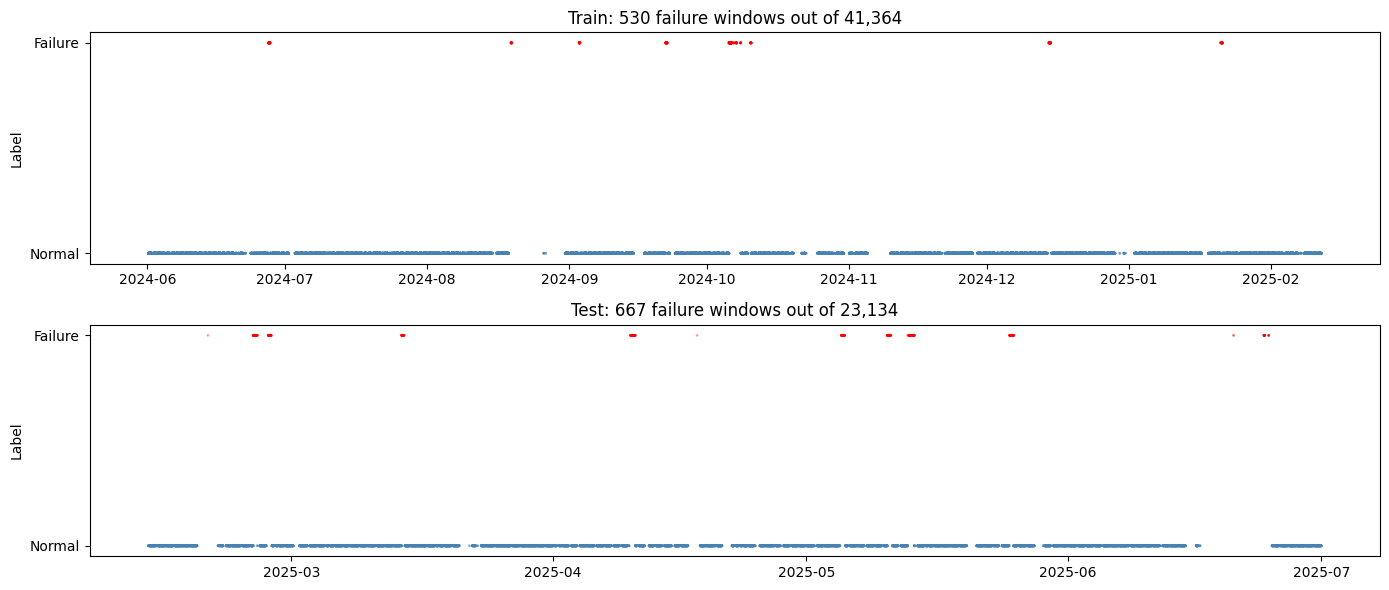

In [3]:
# Label distribution over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, (name, df) in zip(axes, [('Train', sup_train), ('Test', sup_test)]):
    fail_windows = df[df['label'] == 1]
    ax.scatter(df['window_end'], df['label'], s=1, alpha=0.3, c=df['label'].map({0: 'steelblue', 1: 'red'}))
    ax.set_ylabel('Label')
    ax.set_title(f'{name}: {len(fail_windows)} failure windows out of {len(df):,}')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Normal', 'Failure'])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

## 2. Comparison with Steiner's Baseline Predictions

In [4]:
# Load Steiner's RF test predictions
steiner = pd.read_csv(STEINER_PREDS)
steiner['window_end'] = pd.to_datetime(steiner['window_end'])

print('=== Steiner Baseline Predictions ===')
print(f'Rows: {len(steiner):,}')
print(f'Date range: {steiner["window_end"].min().date()} to {steiner["window_end"].max().date()}')
print(f'Columns: {len(steiner.columns)}')

# Label columns
true_col = '6_2_h_shifted_true_failure_label'
pred_col = '6_2_h_shifted_predicted_failure_label'
prob_col = 'probability_of_failure'

print(f'\nTrue labels:      {steiner[true_col].value_counts().to_dict()}')
print(f'Predicted labels: {steiner[pred_col].value_counts().to_dict()}')

# Steiner's test metrics
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

y_true_s = steiner[true_col].values
y_pred_s = steiner[pred_col].values

f1_s  = f1_score(y_true_s, y_pred_s)
p_s   = precision_score(y_true_s, y_pred_s)
r_s   = recall_score(y_true_s, y_pred_s)
cm_s  = confusion_matrix(y_true_s, y_pred_s)
tn, fp, fn, tp = cm_s.ravel()
far_s = fp / (fp + tn)

print(f'\n--- Steiner RF Test Performance ---')
print(f'F1:        {f1_s:.4f}')
print(f'Precision: {p_s:.4f}')
print(f'Recall:    {r_s:.4f}')
print(f'FAR:       {far_s:.4f}')
print(f'CM: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

=== Steiner Baseline Predictions ===
Rows: 1,674
Date range: 2025-02-16 to 2025-05-27
Columns: 345

True labels:      {0: 1435, 1: 239}
Predicted labels: {1: 1674}



--- Steiner RF Test Performance ---
F1:        0.2499
Precision: 0.1428
Recall:    1.0000
FAR:       1.0000
CM: TN=0, FP=1435, FN=0, TP=239


In [5]:
# Compare our test dataset with Steiner's
print('=== Dataset Comparison ===')
print(f'{"":20s} {"Ours":>10s} {"Steiner":>10s}')
print(f'{"Test windows":20s} {len(sup_test):>10,} {len(steiner):>10,}')
print(f'{"Label=1 count":20s} {int(sup_test["label"].sum()):>10,} {int(steiner[true_col].sum()):>10,}')
print(f'{"Label=1 %":20s} {100*sup_test["label"].mean():>10.2f} {100*steiner[true_col].mean():>10.2f}')
print(f'{"Feature cols":20s} {len(feat_cols):>10} {len(steiner.columns)-5:>10}')
print(f'{"Date start":20s} {str(sup_test["window_end"].min().date()):>10s} {str(steiner["window_end"].min().date()):>10s}')
print(f'{"Date end":20s} {str(sup_test["window_end"].max().date()):>10s} {str(steiner["window_end"].max().date()):>10s}')

# Check overlapping time coverage
our_times = set(sup_test['window_end'].dt.date)
steiner_times = set(steiner['window_end'].dt.date)
common = our_times & steiner_times
print(f'\nOverlapping dates: {len(common)} | Ours only: {len(our_times - steiner_times)} | Steiner only: {len(steiner_times - our_times)}')

=== Dataset Comparison ===
                           Ours    Steiner
Test windows             23,134      1,674
Label=1 count               667        239
Label=1 %                  2.88      14.28
Feature cols                340        340
Date start           2025-02-12 2025-02-16
Date end             2025-07-01 2025-05-27

Overlapping dates: 49 | Ours only: 81 | Steiner only: 0


In [6]:
# Compare asset lookback features
print('=== Asset Lookback Features ===')

for feat in ['days_since_last_failure', 'days_since_last_revision']:
    print(f'\n--- {feat} ---')
    print(f'{"":15s} {"mean":>10s} {"std":>10s} {"min":>10s} {"max":>10s}')
    for name, df in [('Ours train', sup_train), ('Ours test', sup_test)]:
        if feat in df.columns:
            s = df[feat].dropna()
            print(f'{name:15s} {s.mean():>10.2f} {s.std():>10.2f} {s.min():>10.2f} {s.max():>10.2f}')
    if feat in steiner.columns:
        s = steiner[feat].dropna()
        print(f'{"Steiner test":15s} {s.mean():>10.2f} {s.std():>10.2f} {s.min():>10.2f} {s.max():>10.2f}')

# NaN check
nan_pct_train = 100 * sup_train[feat_cols].isna().mean()
nan_pct_test  = 100 * sup_test[feat_cols].isna().mean()
cols_with_nan = nan_pct_train[nan_pct_train > 0].index.tolist() + nan_pct_test[nan_pct_test > 0].index.tolist()
print(f'\nFeatures with NaN: {len(set(cols_with_nan))} out of {len(feat_cols)}')
if cols_with_nan:
    for c in sorted(set(cols_with_nan)):
        print(f'  {c}: train={nan_pct_train.get(c, 0):.1f}%, test={nan_pct_test.get(c, 0):.1f}%')

=== Asset Lookback Features ===

--- days_since_last_failure ---
                      mean        std        min        max
Ours train           18.05      13.33       0.00      52.72
Ours test             9.53       7.34       0.00      30.23
Steiner test          7.70       7.29       0.00      28.70

--- days_since_last_revision ---
                      mean        std        min        max
Ours train           14.61      10.69       0.03      54.92
Ours test            13.32       8.57       0.04      31.38
Steiner test         15.13       9.25       0.18      31.38

Features with NaN: 2 out of 340
  days_since_last_failure: train=10.9%, test=0.0%
  days_since_last_revision: train=12.8%, test=0.0%


## 3. Feature Distributions (Normal vs Failure)

In [7]:
# Analyze feature separability between normal and failure windows
# Using train set to avoid data leakage

normal = sup_train[sup_train['label'] == 0]
failure = sup_train[sup_train['label'] == 1]

# Compute effect size (Cohen's d) for each feature
effect_sizes = []
for c in feat_cols:
    n_mean, n_std = normal[c].mean(), normal[c].std()
    f_mean, f_std = failure[c].mean(), failure[c].std()
    pooled_std = np.sqrt((n_std**2 + f_std**2) / 2)
    if pooled_std > 0:
        d = abs(f_mean - n_mean) / pooled_std
    else:
        d = 0.0
    effect_sizes.append({'feature': c, 'cohen_d': d, 'normal_mean': n_mean, 'failure_mean': f_mean})

eff_df = pd.DataFrame(effect_sizes).sort_values('cohen_d', ascending=False)

print('=== Top 20 Most Discriminative Features (by Cohen\'s d) ===')
print(f'{"Rank":>4s}  {"Feature":50s}  {"Cohen d":>8s}  {"Normal μ":>12s}  {"Failure μ":>12s}')
for i, row in eff_df.head(20).iterrows():
    rank = eff_df.index.get_loc(i) + 1
    print(f'{rank:4d}  {row["feature"]:50s}  {row["cohen_d"]:8.3f}  {row["normal_mean"]:12.2f}  {row["failure_mean"]:12.2f}')

=== Top 20 Most Discriminative Features (by Cohen's d) ===
Rank  Feature                                              Cohen d      Normal μ     Failure μ
   1  MW4_LOAD_PRESSURE_BOGIE1_max                           1.464          0.27          0.19
   2  MW3_SPRING_BRAKE_PRESSURE_BOGIE2_sum                   1.333        218.13        120.72
   3  MW3_SPRING_BRAKE_PRESSURE_BOGIE2_mean                  1.323          0.66          0.38
   4  MW3_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2_flips     1.316          6.43          1.40
   5  TRAIN_SPEED_ACTUAL_max                                 1.308          0.74          0.21
   6  CW2_LOAD_PRESSURE_BOGIE2_max                           1.295          0.29          0.22
   7  MW3_LOAD_PRESSURE_BOGIE2_max                           1.285          0.27          0.16
   8  CW1_SPRING_BRAKE_PRESSURE_BOGIE1_sum                   1.280        204.26        114.24
   9  CW1_SPRING_BRAKE_PRESSURE_BOGIE1_mean                  1.272          0.61  

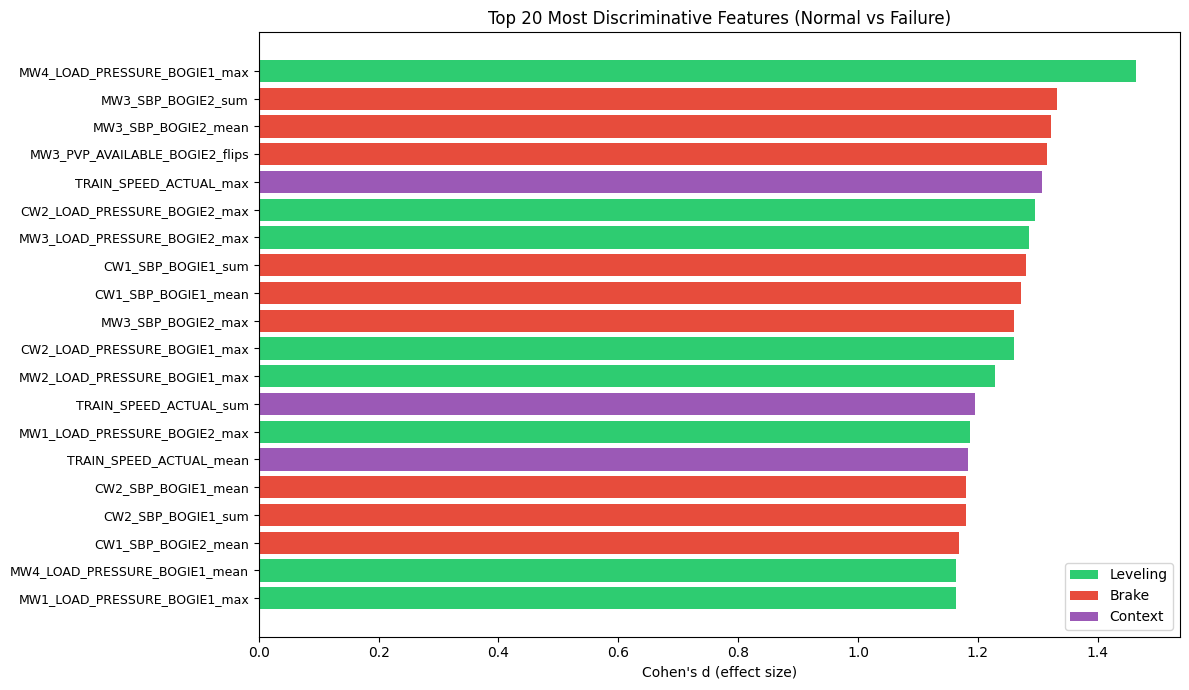

In [8]:
# Bar chart: top 20 features by effect size
top20 = eff_df.head(20).copy()
top20['short_name'] = top20['feature'].str.replace('PROPORTIONAL_VALVE_PRESSURE_', 'PVP_').str.replace('BRAKE_CYLINDER_PRESSURE_', 'BCP_').str.replace('SPRING_BRAKE_PRESSURE_', 'SBP_').str.replace('PNEUMATIC_BRAKING_FORCE_', 'PBF_').str.replace('MAIN_RESERVOIR_PRESSURE', 'MRP').str.replace('ENERGY_BRAKING_RESISTANCE', 'EBR')

# Map to subsystem by extracting sensor name from feature
def feat_to_subsystem(feat_name):
    for suffix in ['_min', '_max', '_mean', '_sum', '_active_s', '_flips']:
        if feat_name.endswith(suffix):
            sensor = feat_name[:-len(suffix)]
            return sensor_to_subsystem(sensor)
    if feat_name.startswith('days_since'):
        return 'Asset'
    return 'Unknown'

top20['subsystem'] = top20['feature'].apply(feat_to_subsystem)
colors = {'Brake': '#e74c3c', 'APU': '#3498db', 'Leveling': '#2ecc71', 'Traction': '#f39c12', 'Context': '#9b59b6', 'Asset': '#34495e', 'Unknown': '#95a5a6'}

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top20)), top20['cohen_d'].values, color=[colors.get(s, '#95a5a6') for s in top20['subsystem']])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['short_name'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Cohen's d (effect size)")
ax.set_title('Top 20 Most Discriminative Features (Normal vs Failure)')

# Legend
from matplotlib.patches import Patch
present = top20['subsystem'].unique()
legend_handles = [Patch(facecolor=colors.get(s, '#95a5a6'), label=s) for s in present]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.show()

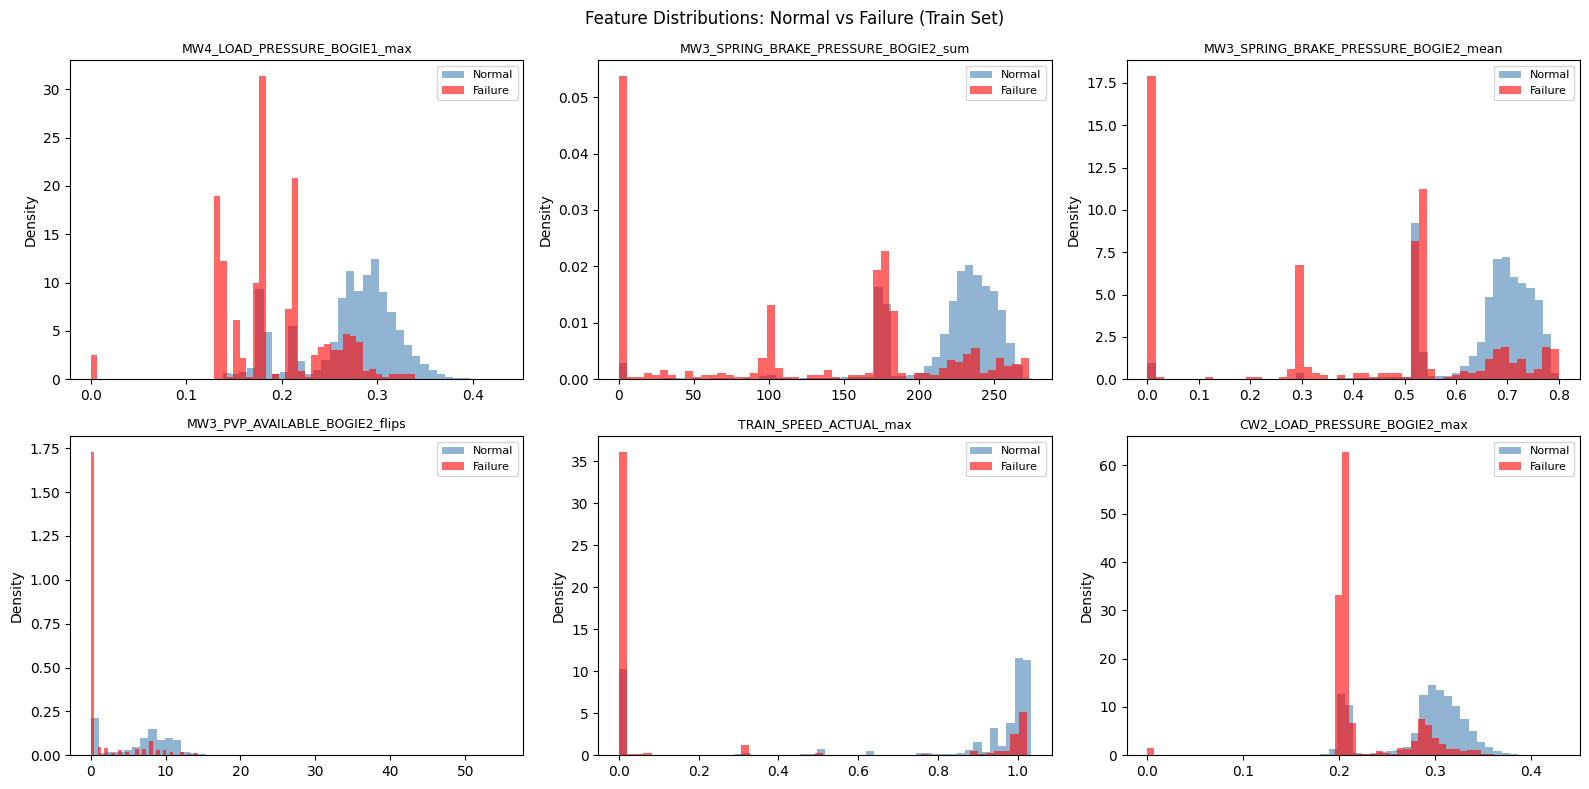

In [9]:
# Distribution plots for top 6 features
top6 = eff_df.head(6)['feature'].values

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, top6):
    ax.hist(normal[feat].dropna(), bins=50, alpha=0.6, label='Normal', density=True, color='steelblue')
    ax.hist(failure[feat].dropna(), bins=50, alpha=0.6, label='Failure', density=True, color='red')
    ax.set_title(feat.replace('PROPORTIONAL_VALVE_PRESSURE_', 'PVP_')[:40], fontsize=9)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions: Normal vs Failure (Train Set)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Subsystem-Level Feature Analysis

In [10]:
# Map every feature to its subsystem
eff_df['subsystem'] = eff_df['feature'].apply(feat_to_subsystem)

# Subsystem summary statistics
print('=== Discriminative Power by Subsystem ===')
print(f'{"Subsystem":12s} {"# Features":>10s} {"Mean |d|":>10s} {"Max |d|":>10s} {"# d>0.3":>8s} {"# d>0.5":>8s}')

for ss in ['Brake', 'APU', 'Leveling', 'Traction', 'Context', 'Asset']:
    sub = eff_df[eff_df['subsystem'] == ss]
    if len(sub) == 0:
        continue
    print(f'{ss:12s} {len(sub):>10d} {sub["cohen_d"].mean():>10.3f} {sub["cohen_d"].max():>10.3f} '
          f'{(sub["cohen_d"] > 0.3).sum():>8d} {(sub["cohen_d"] > 0.5).sum():>8d}')

=== Discriminative Power by Subsystem ===
Subsystem    # Features   Mean |d|    Max |d|  # d>0.3  # d>0.5
Brake               230      0.747      1.333      203      177
APU                  12      0.243      0.418        5        0
Leveling             72      0.622      1.464       52       45
Traction             16      0.166      0.318        4        0
Context               8      0.651      1.308        6        3
Asset                 2      0.174      0.323        1        0


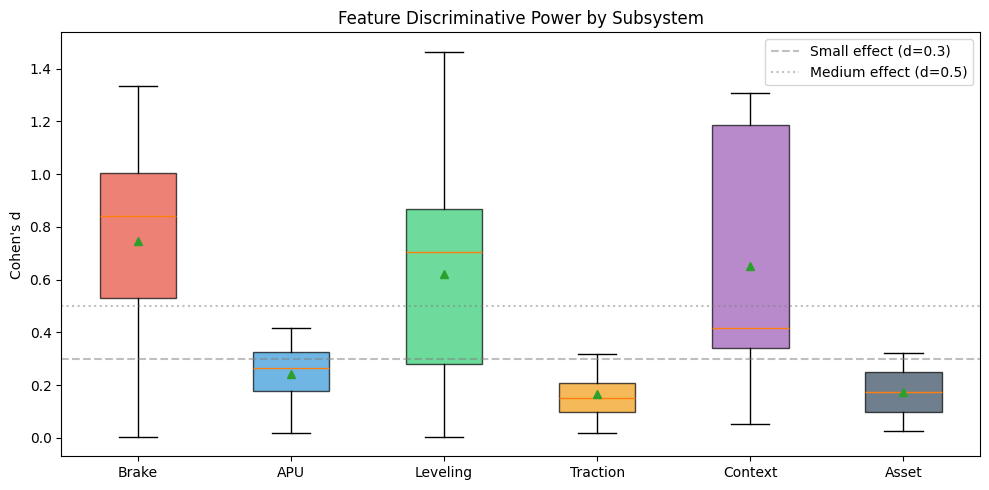

In [11]:
# Box plot of effect sizes by subsystem
fig, ax = plt.subplots(figsize=(10, 5))

subsystems_order = ['Brake', 'APU', 'Leveling', 'Traction', 'Context', 'Asset']
data_for_box = [eff_df[eff_df['subsystem'] == ss]['cohen_d'].values for ss in subsystems_order]
# Filter out empty subsystems
valid = [(ss, d) for ss, d in zip(subsystems_order, data_for_box) if len(d) > 0]
ss_labels, ss_data = zip(*valid)

bp = ax.boxplot(ss_data, labels=ss_labels, patch_artist=True, showmeans=True)
for patch, ss in zip(bp['boxes'], ss_labels):
    patch.set_facecolor(colors.get(ss, '#95a5a6'))
    patch.set_alpha(0.7)

ax.set_ylabel("Cohen's d")
ax.set_title('Feature Discriminative Power by Subsystem')
ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5, label='Small effect (d=0.3)')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Medium effect (d=0.5)')
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
# Within-subsystem correlation (mean pairwise correlation for failure windows)
print('=== Within-Subsystem Feature Correlation (Failure Windows) ===')

for ss in ['Brake', 'APU', 'Leveling', 'Traction']:
    ss_feats = [c for c in feat_cols if feat_to_subsystem(c) == ss]
    if len(ss_feats) < 2:
        continue
    # Use mean features only to avoid redundancy
    mean_feats = [c for c in ss_feats if c.endswith('_mean')]
    if len(mean_feats) < 2:
        mean_feats = ss_feats[:min(10, len(ss_feats))]
    
    corr_fail   = failure[mean_feats].corr().values
    corr_normal = normal[mean_feats].corr().values
    
    # Mean off-diagonal correlation
    mask = ~np.eye(len(mean_feats), dtype=bool)
    mean_corr_fail   = np.abs(corr_fail[mask]).mean()
    mean_corr_normal = np.abs(corr_normal[mask]).mean()
    
    print(f'{ss:12s}: {len(mean_feats):2d} mean-feats | '
          f'Avg |r| normal={mean_corr_normal:.3f}, failure={mean_corr_fail:.3f}')

=== Within-Subsystem Feature Correlation (Failure Windows) ===
Brake       : 48 mean-feats | Avg |r| normal=0.793, failure=0.441
APU         :  2 mean-feats | Avg |r| normal=0.979, failure=0.601
Leveling    : 18 mean-feats | Avg |r| normal=0.496, failure=0.334
Traction    :  4 mean-feats | Avg |r| normal=0.975, failure=0.984


## 5. Unsupervised Dataset Overview

In [13]:
# Load metadata
with open(os.path.join(UNSUP_DIR, 'metadata.json')) as f:
    meta = json.load(f)

print('=== Unsupervised Dataset (LSTM-AE Baseline) ===')
print(f'Channels:     {meta["n_channels"]}')
print(f'Sequence len: {meta["seq_len_s"]}s ({meta["seq_len_s"]/60:.0f} min)')
print(f'Label horizon: {meta["label_horizon_s"]}s ({meta["label_horizon_s"]/3600:.1f}h)')

print(f'\n--- Splits ---')
for split_name, info in meta['splits'].items():
    shape_str = 'x'.join(map(str, info['shape']))
    size_mb = np.prod(info['shape']) * 4 / 1e6  # float32
    extra = f' | type={info["type"]}' if 'type' in info else f' | failures={info.get("n_failure", "?")}'
    print(f'  {split_name:10s}: {shape_str:25s} ({size_mb:,.0f} MB){extra}')

=== Unsupervised Dataset (LSTM-AE Baseline) ===
Channels:     95
Sequence len: 1402s (23 min)
Label horizon: 11163s (3.1h)

--- Splits ---
  train     : 6272x1402x95              (3,341 MB) | type=normal-only
  val       : 1568x1402x95              (835 MB) | type=normal-only
  dev_eval  : 1975x1402x95              (1,052 MB) | failures=8
  test      : 5374x1402x95              (2,863 MB) | failures=46


In [14]:
# Verify standardization: sample train sequences and check stats
train_seqs = np.load(os.path.join(UNSUP_DIR, 'train.npy'), mmap_mode='r')
val_seqs   = np.load(os.path.join(UNSUP_DIR, 'val.npy'), mmap_mode='r')

# Compute channel-wise stats on a sample
n_sample = min(500, train_seqs.shape[0])
sample = train_seqs[:n_sample].reshape(-1, train_seqs.shape[-1])

ch_means = sample.mean(axis=0)
ch_stds  = sample.std(axis=0)

print('=== Standardization Check (first 500 train sequences) ===')
print(f'Channel means: min={ch_means.min():.4f}, max={ch_means.max():.4f}, avg={ch_means.mean():.4f}')
print(f'Channel stds:  min={ch_stds.min():.4f}, max={ch_stds.max():.4f}, avg={ch_stds.mean():.4f}')

# Show any channels with unusual stats
bad_mean = np.where(np.abs(ch_means) > 1.0)[0]
bad_std  = np.where((ch_stds < 0.1) | (ch_stds > 5.0))[0]
if len(bad_mean) > 0:
    print(f'\nChannels with |mean| > 1.0: {len(bad_mean)}')
    for idx in bad_mean[:5]:
        print(f'  ch{idx} ({meta["channels"][idx]}): mean={ch_means[idx]:.3f}, std={ch_stds[idx]:.3f}')
if len(bad_std) > 0:
    print(f'\nChannels with std outside [0.1, 5.0]: {len(bad_std)}')
    for idx in bad_std[:5]:
        print(f'  ch{idx} ({meta["channels"][idx]}): mean={ch_means[idx]:.3f}, std={ch_stds[idx]:.3f}')

if len(bad_mean) == 0 and len(bad_std) == 0:
    print('All channels look well-standardized.')

=== Standardization Check (first 500 train sequences) ===
Channel means: min=-1.4585, max=0.7068, avg=-0.0250
Channel stds:  min=0.0096, max=1.1967, avg=0.8598

Channels with |mean| > 1.0: 2
  ch70 (MW3_ENERGY_BRAKING_RESISTANCE): mean=-1.459, std=0.021
  ch71 (MW4_ENERGY_BRAKING_RESISTANCE): mean=-1.168, std=0.010

Channels with std outside [0.1, 5.0]: 4
  ch68 (MW1_ENERGY_BRAKING_RESISTANCE): mean=0.539, std=0.022
  ch69 (MW2_ENERGY_BRAKING_RESISTANCE): mean=0.331, std=0.024
  ch70 (MW3_ENERGY_BRAKING_RESISTANCE): mean=-1.459, std=0.021
  ch71 (MW4_ENERGY_BRAKING_RESISTANCE): mean=-1.168, std=0.010


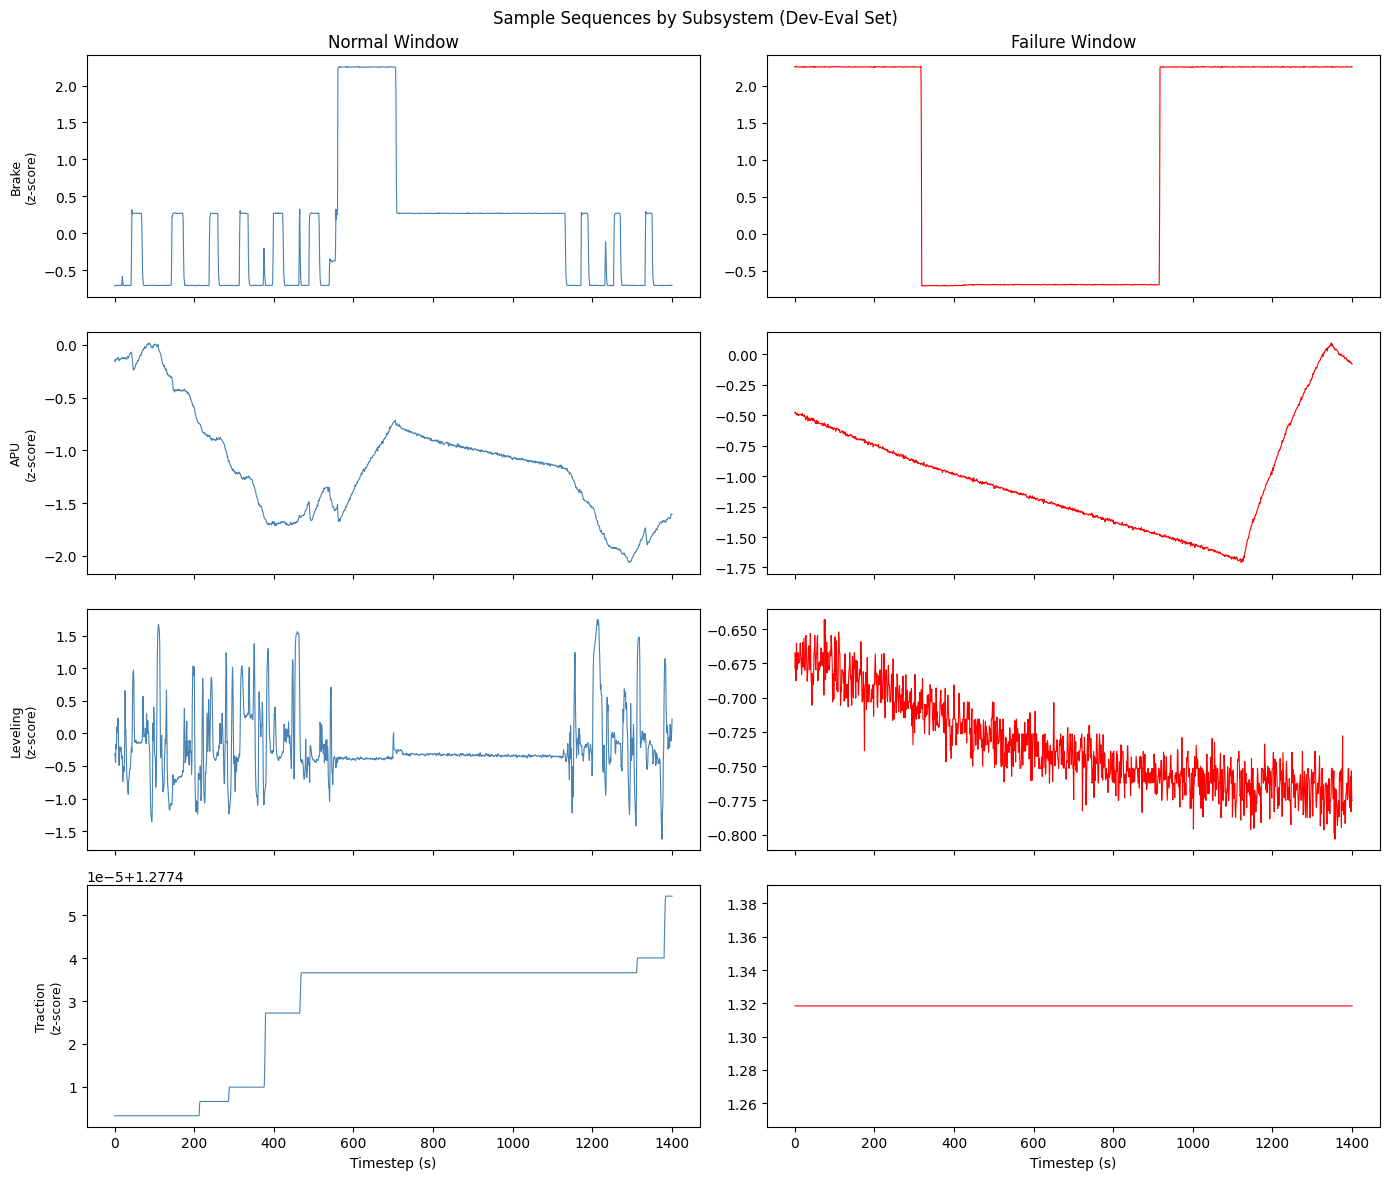

Dev-eval: 1967 normal, 8 failure windows


In [15]:
# Visualize sample sequences: normal vs failure from dev_eval
dev_seqs   = np.load(os.path.join(UNSUP_DIR, 'dev_eval.npy'), mmap_mode='r')
dev_labels = np.load(os.path.join(UNSUP_DIR, 'dev_eval_labels.npy'))

normal_idx = np.where(dev_labels == 0)[0]
fail_idx   = np.where(dev_labels == 1)[0]

# Pick a few representative channels (one per subsystem)
channels = meta['channels']
example_channels = {
    'Brake': channels.index('CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1') if 'CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1' in channels else 0,
    'APU': channels.index('CW1_MAIN_RESERVOIR_PRESSURE') if 'CW1_MAIN_RESERVOIR_PRESSURE' in channels else 1,
    'Leveling': channels.index('CW1_LOAD_PRESSURE_BOGIE1') if 'CW1_LOAD_PRESSURE_BOGIE1' in channels else 2,
    'Traction': channels.index('MW1_ENERGY_BRAKING_RESISTANCE') if 'MW1_ENERGY_BRAKING_RESISTANCE' in channels else 3,
}

fig, axes = plt.subplots(len(example_channels), 2, figsize=(14, 3*len(example_channels)), sharex=True)

for row, (ss_name, ch_idx) in enumerate(example_channels.items()):
    # Normal example
    n_ex = dev_seqs[normal_idx[0], :, ch_idx]
    axes[row, 0].plot(n_ex, color='steelblue', linewidth=0.8)
    axes[row, 0].set_ylabel(f'{ss_name}\n(z-score)', fontsize=9)
    if row == 0:
        axes[row, 0].set_title('Normal Window')
    
    # Failure example
    if len(fail_idx) > 0:
        f_ex = dev_seqs[fail_idx[0], :, ch_idx]
        axes[row, 1].plot(f_ex, color='red', linewidth=0.8)
    if row == 0:
        axes[row, 1].set_title('Failure Window')

axes[-1, 0].set_xlabel('Timestep (s)')
axes[-1, 1].set_xlabel('Timestep (s)')
plt.suptitle('Sample Sequences by Subsystem (Dev-Eval Set)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Dev-eval: {len(normal_idx)} normal, {len(fail_idx)} failure windows')

## 6. Temporal Coverage & Gap Analysis

In [16]:
# Check temporal coverage of supervised windows
print('=== Temporal Coverage ===')

for name, df in [('Train', sup_train), ('Test', sup_test)]:
    ts = df['window_end'].sort_values()
    dt = ts.diff().dt.total_seconds()
    
    print(f'\n--- {name} ---')
    print(f'  Span: {ts.min().date()} to {ts.max().date()} ({(ts.max() - ts.min()).days} days)')
    print(f'  Windows: {len(ts):,}')
    print(f'  Median gap: {dt.median():.0f}s ({dt.median()/60:.1f} min)')
    print(f'  Max gap:    {dt.max():.0f}s ({dt.max()/3600:.1f}h)')
    
    # Count gaps > 1 hour (train not running)
    big_gaps = dt[dt > 3600]
    print(f'  Gaps > 1h:  {len(big_gaps)} (operational breaks / maintenance)')
    
    # Windows per day
    daily = df.groupby(df['window_end'].dt.date).size()
    print(f'  Windows/day: mean={daily.mean():.0f}, min={daily.min()}, max={daily.max()}')

=== Temporal Coverage ===

--- Train ---
  Span: 2024-06-01 to 2025-02-12 (255 days)
  Windows: 41,364
  Median gap: 350s (5.8 min)
  Max gap:    600600s (166.8h)
  Gaps > 1h:  360 (operational breaks / maintenance)
  Windows/day: mean=177, min=1, max=238

--- Test ---
  Span: 2025-02-12 to 2025-07-01 (138 days)
  Windows: 23,134
  Median gap: 350s (5.8 min)
  Max gap:    343000s (95.3h)
  Gaps > 1h:  210 (operational breaks / maintenance)
  Windows/day: mean=178, min=1, max=239


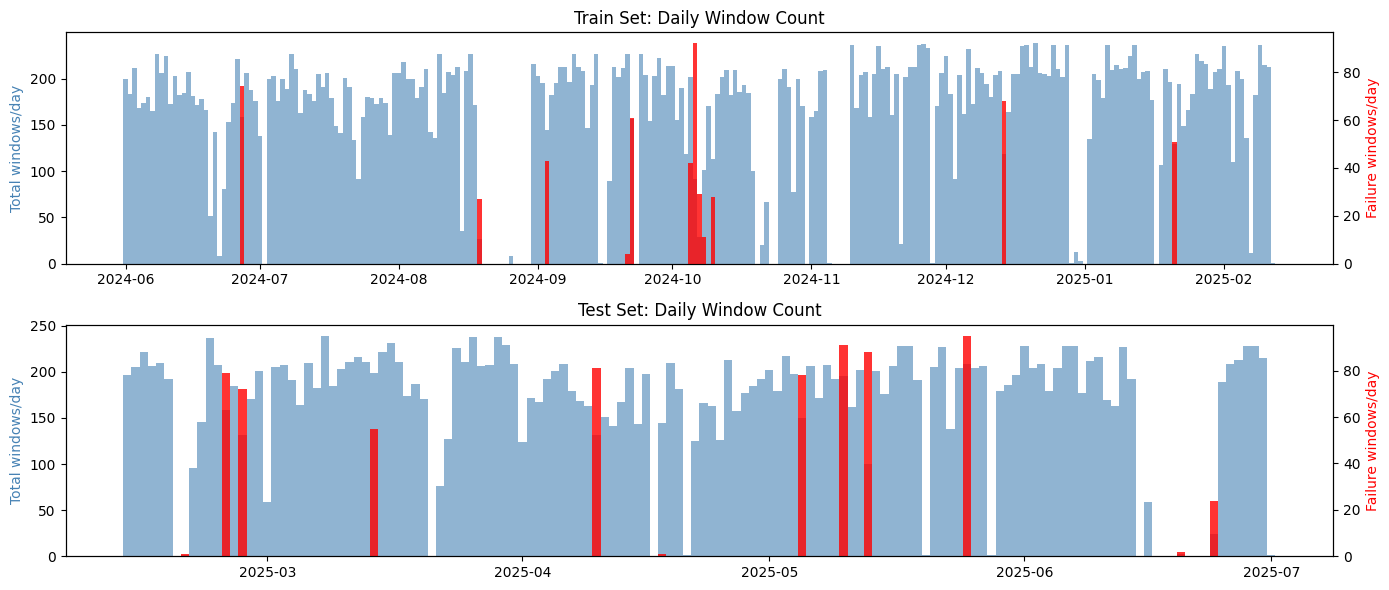

In [17]:
# Daily window count with failure overlay
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, (name, df) in zip(axes, [('Train', sup_train), ('Test', sup_test)]):
    daily = df.groupby(df['window_end'].dt.date).agg(
        count=('label', 'size'),
        failures=('label', 'sum')
    )
    daily.index = pd.to_datetime(daily.index)
    
    ax.bar(daily.index, daily['count'], width=1, color='steelblue', alpha=0.6, label='Total windows')
    ax2 = ax.twinx()
    fail_days = daily[daily['failures'] > 0]
    ax2.bar(fail_days.index, fail_days['failures'], width=1, color='red', alpha=0.8, label='Failure windows')
    
    ax.set_ylabel('Total windows/day', color='steelblue')
    ax2.set_ylabel('Failure windows/day', color='red')
    ax.set_title(f'{name} Set: Daily Window Count')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [18]:
# Summary table
print('\n' + '='*70)
print('DATASET ANALYSIS SUMMARY')
print('='*70)

print(f'\nSupervised (RF baseline, Wfeat=350s, Wlabel=22326s):')
print(f'  Train: {len(sup_train):,} windows, {int(sup_train["label"].sum())} failure ({100*sup_train["label"].mean():.2f}%)')
print(f'  Test:  {len(sup_test):,} windows, {int(sup_test["label"].sum())} failure ({100*sup_test["label"].mean():.2f}%)')
print(f'  Features: {len(feat_cols)} ({len(analog_feats)} analog + {len(binary_feats)} binary + {len(asset_feats)} asset)')

print(f'\nUnsupervised (LSTM-AE baseline, Wseq=1402s, Wlabel=11163s):')
for split, info in meta['splits'].items():
    shape_str = 'x'.join(map(str, info['shape']))
    extra = info.get('type', f'failures={info.get("n_failure", "?")}')
    print(f'  {split:10s}: {shape_str} ({extra})')

print(f'\nSteiner baseline test performance:')
print(f'  RF:      F1={f1_s:.4f}, P={p_s:.4f}, R={r_s:.4f}, FAR={far_s:.4f}')
print(f'  Steiner test windows: {len(steiner):,} | Our test windows: {len(sup_test):,}')

# Top discriminative subsystems
ss_summary = eff_df.groupby('subsystem')['cohen_d'].agg(['mean', 'max', 'count'])
ss_summary = ss_summary.sort_values('mean', ascending=False)
print(f'\nMost discriminative subsystems (by mean Cohen\'s d):')
for ss, row in ss_summary.iterrows():
    print(f'  {ss:12s}: mean d={row["mean"]:.3f}, max d={row["max"]:.3f} ({int(row["count"])} features)')

print(f'\nDatasets ready for Phase 2 modeling.')


DATASET ANALYSIS SUMMARY

Supervised (RF baseline, Wfeat=350s, Wlabel=22326s):
  Train: 41,364 windows, 530 failure (1.28%)
  Test:  23,134 windows, 667 failure (2.88%)
  Features: 340 (296 analog + 42 binary + 2 asset)

Unsupervised (LSTM-AE baseline, Wseq=1402s, Wlabel=11163s):
  train     : 6272x1402x95 (normal-only)
  val       : 1568x1402x95 (normal-only)
  dev_eval  : 1975x1402x95 (failures=8)
  test      : 5374x1402x95 (failures=46)

Steiner baseline test performance:
  RF:      F1=0.2499, P=0.1428, R=1.0000, FAR=1.0000
  Steiner test windows: 1,674 | Our test windows: 23,134

Most discriminative subsystems (by mean Cohen's d):
  Brake       : mean d=0.747, max d=1.333 (230 features)
  Context     : mean d=0.651, max d=1.308 (8 features)
  Leveling    : mean d=0.622, max d=1.464 (72 features)
  APU         : mean d=0.243, max d=0.418 (12 features)
  Asset       : mean d=0.174, max d=0.323 (2 features)
  Traction    : mean d=0.166, max d=0.318 (16 features)

Datasets ready for P